# Long short-term memory (LSTM) model

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from nltk.corpus import stopwords
import nltk
nltk.download('stopwords', quiet=True)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout, SpatialDropout1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

In [49]:
df = pd.read_csv('reviews.csv')
print(f"Shape: {df.shape}")
df.head(10)

Shape: (6210, 5)


,review_id,rating,review_text,review_date,helpful
0,981e465b-d3ba-4632-9c60-25051efac38a,5,It's good,11/22/2025 1:19,0
1,964d3555-9429-4c20-8127-ce3c71ce9273,5,WhatsApp not working well always shows offline...,11/24/2025 20:03,0
2,6c28859f-1554-4ca1-9aa8-9d66f204be0a,5,"Oppo not corresponding, share with me the offi...",11/25/2025 6:26,0
3,a7efafc3-5871-4020-a398-9cc12cb4072a,5,"Excellent app, great communication super conne...",11/25/2025 18:09,0
4,de142b31-a5ad-446f-b7c8-51b264728478,4,simply the ɓest for chat and calls.i love it,11/24/2025 1:10,1
5,8b0ffc3b-d7d0-4198-8ce0-763674359246,5,good. but i need WhatsApp premium features,11/26/2025 16:42,0
6,XCdQN9L5-PsBJ-ftUV-Ov6H-Na1v3f0JxTLs,4,learning learning learning learning learning l...,25/11/2025 06:54,1
7,18294fa1-0410-4476-970f-33f188b0abfe,5,Awesome. I just need it to download and install,11/22/2025 20:27,0
8,c9fd6209-d8ed-482e-9b03-68cc2100fed0,5,very nice app thnx so much,11/22/2025 15:53,0
9,75b5068d-6b9b-4aa6-a069-abdb6bfc6388,5,Really really apriacite 100/,11/26/2025 17:06,0


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6210 entries, 0 to 6209
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    6210 non-null   object
 1   rating       6210 non-null   int64 
 2   review_text  6210 non-null   object
 3   review_date  6210 non-null   object
 4   helpful      6210 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 242.7+ KB


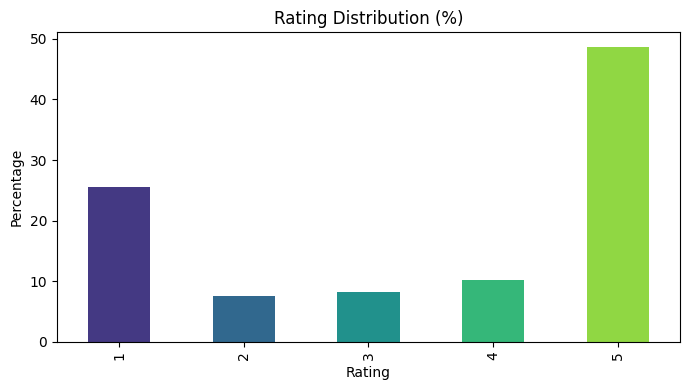

Rating value counts:
rating
1    1582
2     467
3     508
4     632
5    3021
Name: count, dtype: int64


In [51]:
# Rating distribution
fig, ax = plt.subplots(figsize=(7, 4))
rating_pct = df['rating'].value_counts(normalize=True).sort_index() * 100
rating_pct.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', len(rating_pct)))
ax.set_title('Rating Distribution (%)')
ax.set_ylabel('Percentage')
ax.set_xlabel('Rating')
plt.tight_layout()
plt.show()

print("Rating value counts:")
print(df['rating'].value_counts().sort_index())

### Class imbalance

The dataset is heavily imbalanced and rating 5 makes up almost half of the data, while ratings 2 and 3
have very few samples. This might be a problem because the model could simply learn to predict 5 for 
every input, achieving almost accuracy without actually learning anything

**What we did to handle this:**
- **Class weights** during training so we penalise mistakes on minority classes more heavily.
- **Macro-averaged F1** as the main metric. This treats all classes equally regardless of size.

## Text Preprocessing

- **Lowercasing:** Reduces vocabulary size 
- **Remove URLs / emails / special characters:** These carry no sentiment and just add noise
- **Remove extra whitespace:** Normalises the input
- **Stop words** We intentionally keep some stop words like "not", "no", "very" because they carry sentiment.

In [52]:
stop_words = set(stopwords.words('english'))

# Remove sentiment-carrying words from the stopword list
sentiment_keepers = {
    'not', 'no', 'nor', 'never', 'neither', 'nobody', 'nothing', 'nowhere',
    'very', 'too', 'most', 'more', 'less', 'least', 'few',
    'but', 'however', 'although', 'only', 'just',
    'above', 'below', 'again', 'against',
}
stop_words = stop_words - sentiment_keepers

def clean_text(text):
    """Basic text cleaning for LSTM input."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)                      # URLs
    text = re.sub(r'\S+@\S+', '', text)                             # emails
    text = re.sub(r'[^a-z\s]', '', text)                            # keep only letters & spaces
    text = re.sub(r'\s+', ' ', text).strip()                        # whitespace
    text = ' '.join(w for w in text.split() if w not in stop_words) # stopwords
    return text

df['clean_text'] = df['review_text'].apply(clean_text)

# Drop rows if empty
before = len(df)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)
print(f"Dropped {before - len(df)} empty reviews after cleaning.")

Dropped 42 empty reviews after cleaning.


## Tokenisation & Padding

We convert each review into a sequence of integer tokens and pad/truncate to a fixed length
so that every input to the LSTM has the same shape.

**Parameters chosen here:**
- MAX_VOCAB = 20 000 Keeps the most common words because rare words add more noise 
- MAX_LEN = 100 Covers most of the reviews without wasting memory

In [53]:
MAX_VOCAB = 20_000  
MAX_LEN   = 100

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Vocabulary size (total unique tokens): {len(tokenizer.word_index)}")
print(f"Vocabulary size (used): {MAX_VOCAB}")
print(f"Padded sequence shape: {X.shape}")

Vocabulary size (total unique tokens): 6992
Vocabulary size (used): 20000
Padded sequence shape: (6168, 100)


## Prepare Labels & Split Data

The rating column has values 1–5. We subtract 1 so labels become 0–4 which is required by
`to_categorical`. We then split into **train (70 %)**, **validation (15 %)** (used to check early stopping), and **test (15 %)**

In [54]:
NUM_CLASSES = df['rating'].nunique()
y_integer = df['rating'].values - 1  # shift from 1-5 to 0-4
y = to_categorical(y_integer, num_classes=NUM_CLASSES)

X_train, X_temp, y_train, y_temp, idx_train, idx_temp = train_test_split(
    X, y, y_integer, test_size=0.30, random_state=42, stratify=y_integer
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

### Compute class weights

Because the dataset is imbalanced, we compute class weights that are inversely proportional
to class frequency. This is done by Scikit-learn's `compute_class_weight('balanced', ...)`

In [55]:
train_labels = np.argmax(y_train, axis=1)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_labels
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
for cls, weight in class_weight_dict.items():
    print(f"  Rating {cls + 1}: {weight:.3f}")

Class weights:
  Rating 1: 0.784
  Rating 2: 2.707
  Rating 3: 2.460
  Rating 4: 1.985
  Rating 5: 0.409


## Building the model

- `Embedding` Learns a vector for each word
- `SpatialDropout1D(0.3)` Drops some embedding channels which regularises better than normal dropout for sequences 
- `Bidirectional(LSTM(32))` Reads the sequence both forwards and backwards, better for capturing context 
- `Dense(16, relu)` Adds a non-linear transformation 
- `Dropout(0.4)` High dropout to slow overfitting 
- `Dense(softmax)` Outputs a probability distribution for the rating classes 

In [56]:
EMBEDDING_DIM = 64

model = Sequential([
    Embedding(input_dim=MAX_VOCAB,
              output_dim=EMBEDDING_DIM,
              input_length=MAX_LEN),
    SpatialDropout1D(0.3),
    Bidirectional(LSTM(32, dropout=0.3, recurrent_dropout=0.3)),
    Dense(16, activation='relu'),
    Dropout(0.4),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.build(input_shape=(None, MAX_LEN))
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 100, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 100, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,305,957 (4.98 MB)

 Trainable params: 1,305,957 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

## Training the Model

- **Class weights** helps the model pay more attention to underrepresented ratings
- **EarlyStopping** on validation loss with `patience=5`. This stops the training when the model doesn't get any meaningfully better

In [57]:
EPOCHS     = 20
BATCH_SIZE = 32

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 33s 168ms/step - accuracy: 0.3185 - loss: 1.6037 - val_accuracy: 0.4627 - val_loss: 1.5392
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 25s 183ms/step - accuracy: 0.3850 - loss: 1.5602 - val_accuracy: 0.5686 - val_loss: 1.4232
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 26s 194ms/step - accuracy: 0.4610 - loss: 1.4717 - val_accuracy: 0.4800 - val_loss: 1.4058
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 27s 196ms/step - accuracy: 0.5080 - loss: 1.3696 - val_accuracy: 0.4897 - val_loss: 1.3752
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 29s 216ms/step - accuracy: 0.5383 - loss: 1.2776 - val_accuracy: 0.5081 - val_loss: 1.3444
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 26s 191ms/step - accuracy: 0.5770 - loss: 1.1775 - val_accuracy: 0.5103 - val_loss: 1.3756
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 27s 201ms/step - accuracy: 0.6092 - loss: 1.0894 - val_accuracy: 0.5016 - val_loss: 1.4013
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 26s 191ms/step - accuracy: 0.6305 - loss: 1

## Evaluation on Test Set

- **Accuracy** overall fraction of correct predictions
- **Classification report** precision, recall, and F1 per class. The Macro avg F1 is the
  most meaningful metric here because it treats all classes equally
- **Confusion matrix** shows where the model makes mistakes

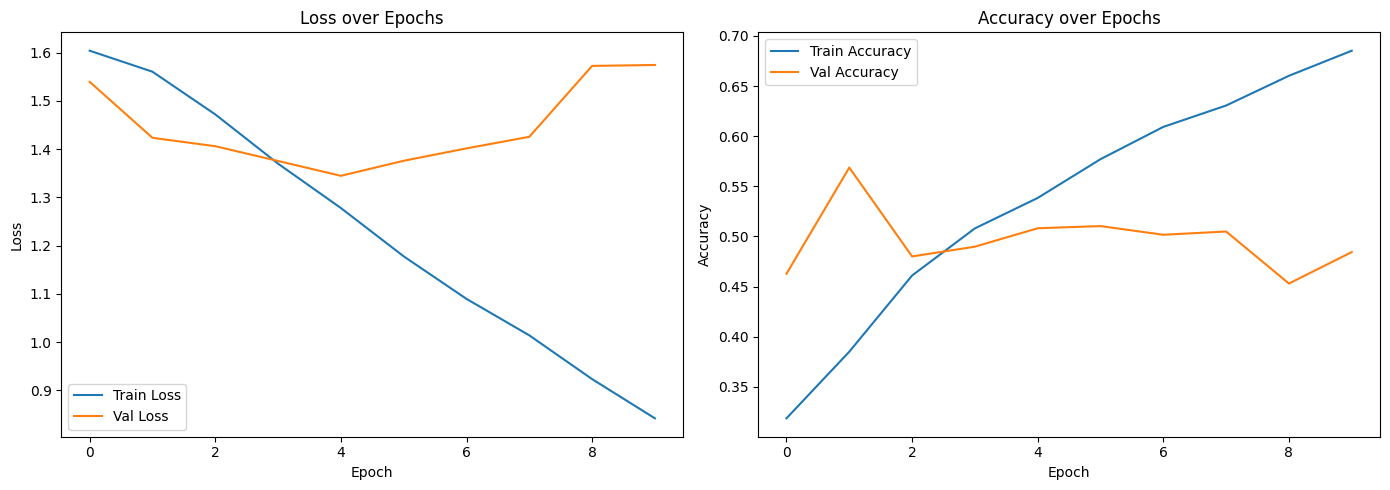

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'],  label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'],  label='Val Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

**Loss and accuracy**
As we see on the graph, around the third/fourth epoch is where the model starts to overfit. 
Learning the training data (getting better training accuracy), but not improving its test accuracy

In [59]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.4f}\n")

# Classification report (labels shifted back to 1-5 for readability)
target_names = [f"Rating {i}" for i in range(1, NUM_CLASSES + 1)]
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))

29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step
Test Accuracy: 0.4849

              precision    recall  f1-score   support

    Rating 1       0.46      0.52      0.49       239
    Rating 2       0.15      0.19      0.17        68
    Rating 3       0.17      0.27      0.21        90
    Rating 4       0.14      0.08      0.10        91
    Rating 5       0.75      0.64      0.69       438

    accuracy                           0.48       926
   macro avg       0.33      0.34      0.33       926
weighted avg       0.51      0.48      0.49       926



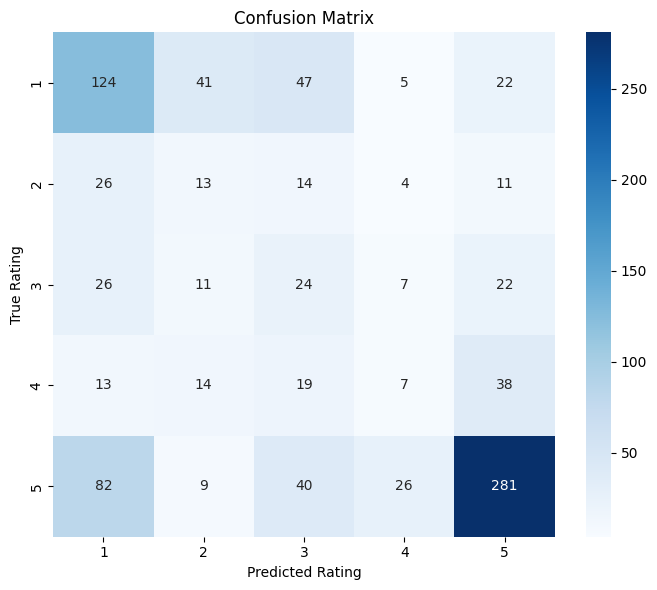

In [60]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, NUM_CLASSES + 1),
            yticklabels=range(1, NUM_CLASSES + 1))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Rating')
plt.ylabel('True Rating')
plt.tight_layout()
plt.show()

## Summary 

### Results

Our LSTM achieves around 54% test accuracy** and a macro F1 of around 0.34 on 5-class
review rating prediction. While these numbers might not be the best, the model does however demonstrate learning:

- **Ratings 1 and 5** are predicted well (F1 of 0.53 and 0.75). The model has
  learned to distinguish clearly positive from clearly negative sentiment
- **Ratings 2, 3, and 4** are poorly predicted (F1 of 0.12–0.16). These classes have far fewer
  training samples (61–90 test samples vs 229–471 for ratings 1 and 5) and their review texts
  are often ambiguous

### Why might the performance be limited?

- **Severe class imbalance:** Rating 5 has almost half of the samples while rating 2 has less than 10%. Even with
   class weights, the model has far fewer examples to learn what a 2-star review looks like
- **Short, uninformative reviews:** Many reviews are just 1–3 words.
There is simply not enough text to distinguish a 4-star rating from a 5-star one
- **Noisy labels:** Some 5-star reviews contain complaints and some 1-star 
reviews mention positive features. The text-rating is not perfect 
- **Small dataset:** ~6200 reviews is small for training an LSTM with a 20 000-word
   vocabulary. The embedding layer alone has 1.28M parameters which is far more than the number of
   training samples
- **Overfitting:** Despite regularisation (dropout, smaller architecture), the model begins
   overfitting around epoch 3-4, as we can see by the divergence between training and
   validation loss

### Steps taken to improve performance

- **Class weights** (`compute_class_weight('balanced')`) 
- **Bidirectional LSTM** allows the model to capture context from both directions
- **Model size reduction** We reduced the model size throughout (LSTM 64→32, Dense 32→16) and increased dropout (0.2→0.3/0.4)
to try to combat overfitting on the small dataset
- **Text preprocessing** lowercasing, URL/email removal, removing some stop words and keeping others that
  carry sentiment

### Possible further improvements

- **Reduce to 3 classes** (Negative=1–2, Neutral=3, Positive=4–5), this would significantly
   boost performance by grouping ambiguous middle ratings and addressing the imbalance in the dataset
- **Transformer-based models** Using a more complex transformer like BERT. These models typically outperform LSTMs significantly on text
   classification tasks, especially with small datasets
